# Manual cleanup and Taiwan transaction export

Review OCR rows that need manual attention, apply explicit corrections or exclusions, and create `data/processed/transactions_taiwan_2026.csv` in the schema expected by the Transactions Visualizer.

## Load the actual-image OCR summary

In [2]:
from pathlib import Path

import pandas as pd
from IPython.display import display
from PIL import Image

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent

summary_path = (
    repo_root
    / "outputs"
    / "ocr"
    / "screenshot_20260805_111339"
    / "ocr_image_summary.csv"
)
crop_dir = (
    repo_root
    / "images"
    / "crops"
    / "Screenshot_20260805_111339_alternating_bands"
)
output_path = repo_root / "data" / "processed" / "transactions_taiwan_2026.csv"

summary_df = pd.read_csv(summary_path, parse_dates=["date"])
summary_df["parse_valid"] = (
    summary_df["parse_valid"].fillna(False).astype(str).str.lower().eq("true")
)

print(f"Loaded {len(summary_df)} OCR rows from {summary_path}")
display(summary_df.head())

Loaded 153 OCR rows from C:\Users\Johnson\Desktop\PersonalProjects\TransactionsVisualizer\outputs\ocr\screenshot_20260805_111339\ocr_image_summary.csv


,source_image,detected_text_count,combined_text,mean_confidence,store_name,description,store_confidence,description_confidence,receipt_code,amount,date,parse_valid
0,Screenshot_20260805_111339_band_001_y400-508.jpg,7,尚未 | DQ00509103 | 手機條碼 | 45元 | 開獎 | 得正 輕烏龍 | 0...,0.986583,得正,輕烏龍,0.999780,0.999726,DQ00509103,45.0,2026-08-04,True
1,Screenshot_20260805_111339_band_002_y510-617.jpg,7,尚未 | CJ65374262 | 手機條碼 | 178元 | 開獎 | 全家 明細更新中，...,0.985932,全家,明細更新中，請稍候,0.999749,0.993204,CJ65374262,178.0,2026-08-04,True
2,Screenshot_20260805_111339_band_003_y619-727.jpg,7,尚未 | CJ65374275 | 手機條碼 | 197元 | 開獎 | 全家 明細更新中，...,0.986191,全家,明細更新中，請稍候,0.999404,0.996181,CJ65374275,197.0,2026-08-04,True
3,Screenshot_20260805_111339_band_004_y729-836.jpg,8,尚未 | DH17234686 | 手機條碼 | 45元 | 開獎 | 路易莎咖啡R | 錫...,0.966527,路易莎咖啡,R 錫蘭紅茶-大冰,0.998455,0.928871,DH17234686,45.0,2026-08-03,True
4,Screenshot_20260805_111339_band_005_y838-946.jpg,7,尚未 | DM66256508 | 纸本電子 | 20元 | 開獎 | 萬洲通國際企...置...,0.959596,萬洲通國際企...置物箱使,用费,0.799534,0.821270,DM66256508,20.0,2026-08-03,True


## Show rows where `parse_valid` is False

These rows could not be parsed automatically. Display the relevant OCR fields first, followed by each source crop for visual review.

Rows with parse_valid=False: 7


,source_image,detected_text_count,combined_text,store_name,description,amount,date
113,Screenshot_20260805_111339_band_114_y12774-128...,6,尚未 | CV65883784 | 手機條碼 | 29元 | 開獎 | 7-ELEV.(A)...,7-ELEV...,(A)*台鹽海洋鹼性離子水P.,29.0,NaT
147,Screenshot_20260805_111339_band_148_y16497-166...,5,尚未 | CD76124067 | 傳統發票 | 開獎 | 07-08月,NaN,NaN,NaN,NaT
148,Screenshot_20260805_111339_band_149_y16606-167...,5,尚未 | CD78157036 | 傳統發票 | 開獎 | 07-08月,NaN,NaN,NaN,NaT
149,Screenshot_20260805_111339_band_150_y16716-168...,5,尚未 | CD78789694 | 傳統發票 | 開獎 | 07-08月,NaN,NaN,NaN,NaT
150,Screenshot_20260805_111339_band_151_y16825-169...,0,NaN,NaN,NaN,NaN,NaT
151,Screenshot_20260805_111339_band_152_y16935-170...,3,消费分析 | 日 | 0,目,NaN,NaN,NaT
152,Screenshot_20260805_111339_band_153_y17044-170...,6,首頁 | 活動 | 載具管理 | 掃描對獎 | 我的發票 | 個人,NaN,NaN,NaN,NaT


Screenshot_20260805_111339_band_114_y12774-12881.jpg


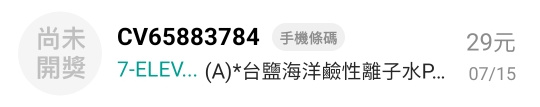

Screenshot_20260805_111339_band_148_y16497-16604.jpg


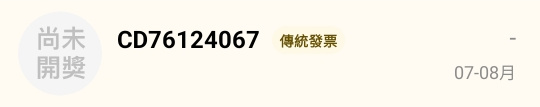

Screenshot_20260805_111339_band_149_y16606-16714.jpg


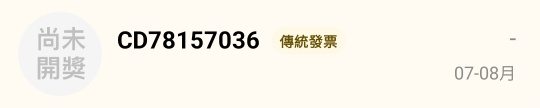

Screenshot_20260805_111339_band_150_y16716-16823.jpg


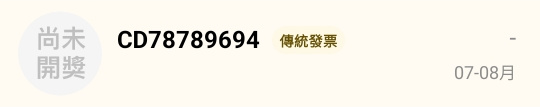

Screenshot_20260805_111339_band_151_y16825-16933.jpg


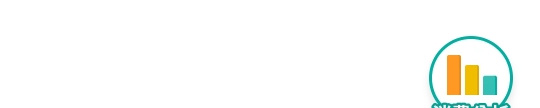

Screenshot_20260805_111339_band_152_y16935-17042.jpg


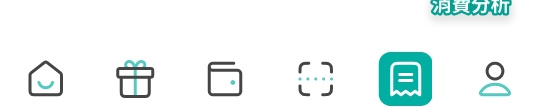

Screenshot_20260805_111339_band_153_y17044-17068.jpg


In [3]:
invalid_rows = summary_df.loc[
    ~summary_df["parse_valid"],
    [
        "source_image",
        "detected_text_count",
        "combined_text",
        "store_name",
        "description",
        "amount",
        "date",
    ],
].copy()

print(f"Rows with parse_valid=False: {len(invalid_rows)}")
display(invalid_rows)

for source_image in invalid_rows["source_image"]:
    image_path = crop_dir / source_image
    print(source_image)
    if image_path.exists():
        with Image.open(image_path) as image:
            display(image.copy())
    else:
        print(f"Missing crop: {image_path}")

## Check for rows missing required export fields

A row can pass the pipe parser but still lack a store name. Such rows also require an explicit manual decision before export.

In [4]:
missing_required = summary_df.loc[
    summary_df["parse_valid"]
    & (
        summary_df["store_name"].fillna("").str.strip().eq("")
        | summary_df["amount"].isna()
        | summary_df["date"].isna()
    ),
    ["source_image", "combined_text", "store_name", "amount", "date"],
].copy()

print(f"Otherwise-valid rows missing an export field: {len(missing_required)}")
display(missing_required)

Otherwise-valid rows missing an export field: 1


,source_image,combined_text,store_name,amount,date
71,Screenshot_20260805_111339_band_072_y8175-8282...,"尚未 | DM12866285 | 纸本電子 | 1,790元 | 開獎 | 07/23",NaN,1790.0,2026-07-23


## Manual cleanup decisions

Edit this dictionary whenever review reveals another correction. `include=True` retains a corrected transaction; `include=False` documents an intentional exclusion.

The 29元 7-ELEVEN row is recoverable: its date was joined to the final text segment. The three traditional-invoice rows contain no store, amount, or purchase date; the remaining bottom crops are navigation/footer artifacts. The 1,790元 row has no merchant text visible in its crop, so it is excluded rather than assigning an invented store name.

In [5]:
manual_cleanup = {
    "Screenshot_20260805_111339_band_114_y12774-12881.jpg": {
        "include": True,
        "store_name": "7-ELEVEN",
        "amount": 29,
        "date": "2026-07-15",
    },
    "Screenshot_20260805_111339_band_148_y16497-16604.jpg": {"include": False},
    "Screenshot_20260805_111339_band_149_y16606-16714.jpg": {"include": False},
    "Screenshot_20260805_111339_band_150_y16716-16823.jpg": {"include": False},
    "Screenshot_20260805_111339_band_151_y16825-16933.jpg": {"include": False},
    "Screenshot_20260805_111339_band_152_y16935-17042.jpg": {"include": False},
    "Screenshot_20260805_111339_band_153_y17044-17068.jpg": {"include": False},
    "Screenshot_20260805_111339_band_072_y8175-8282.jpg": {"include": False},
}

## Apply and validate the cleanup

The validation prevents export when an invalid or incomplete row lacks a documented decision, or when an included row is still missing date, store, or amount.

In [6]:
cleaned_df = summary_df.copy()
cleaned_df["include"] = cleaned_df["parse_valid"]

review_sources = set(invalid_rows["source_image"]) | set(missing_required["source_image"])
undecided_sources = review_sources - set(manual_cleanup)
if undecided_sources:
    raise ValueError(f"Manual cleanup decisions are missing for: {sorted(undecided_sources)}")

unknown_sources = set(manual_cleanup) - set(cleaned_df["source_image"])
if unknown_sources:
    raise ValueError(f"Manual cleanup refers to unknown images: {sorted(unknown_sources)}")

for source_image, changes in manual_cleanup.items():
    row_mask = cleaned_df["source_image"].eq(source_image)
    cleaned_df.loc[row_mask, "include"] = changes["include"]
    for field in ("store_name", "amount", "date"):
        if field in changes:
            cleaned_df.loc[row_mask, field] = changes[field]

cleaned_df["date"] = pd.to_datetime(cleaned_df["date"], errors="coerce")
cleaned_df["amount"] = pd.to_numeric(cleaned_df["amount"], errors="coerce")

included_df = cleaned_df.loc[cleaned_df["include"]].copy()
missing_after_cleanup = included_df.loc[
    included_df["date"].isna()
    | included_df["amount"].isna()
    | included_df["store_name"].fillna("").str.strip().eq("")
]
if not missing_after_cleanup.empty:
    raise ValueError(
        "Included rows still have missing required fields: "
        + str(missing_after_cleanup["source_image"].tolist())
    )

print(f"Rows retained: {len(included_df)}")
print(f"Rows excluded: {len(cleaned_df) - len(included_df)}")

Rows retained: 146
Rows excluded: 7


## Build and export the processed transactions

`description_normalized` comes from the cleaned store name and `debit` comes from the OCR amount. Category fields are intentionally blank for future classification.

In [7]:
transactions_df = pd.DataFrame(
    {
        "date": included_df["date"],
        "description_normalized": included_df["store_name"].str.strip(),
        "debit": included_df["amount"],
        "category": pd.NA,
        "subcategory": pd.NA,
    }
)
transactions_df = transactions_df[
    ["date", "description_normalized", "debit", "category", "subcategory"]
].reset_index(drop=True)
transactions_df["debit"] = transactions_df["debit"].astype("Int64")

output_path.parent.mkdir(parents=True, exist_ok=True)
transactions_df.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%d",
)

print(f"Saved {len(transactions_df)} transactions to {output_path}")
display(transactions_df)

Saved 146 transactions to C:\Users\Johnson\Desktop\PersonalProjects\TransactionsVisualizer\data\processed\transactions_taiwan_2026.csv


,date,description_normalized,debit,category,subcategory
0,2026-08-04,得正,45,<NA>,<NA>
1,2026-08-04,全家,178,<NA>,<NA>
2,2026-08-04,全家,197,<NA>,<NA>
3,2026-08-03,路易莎咖啡,45,<NA>,<NA>
4,2026-08-03,萬洲通國際企...置物箱使,20,<NA>,<NA>
...,...,...,...,...,...
141,2026-07-07,鶴茶樓本部股...鶴頂紅茶,35,<NA>,<NA>
142,2026-07-07,安好有限公司..文具用品,400,<NA>,<NA>
143,2026-07-07,伊勝實業有限...麵包,70,<NA>,<NA>
144,2026-07-07,統一生活事業...#.Ng99,574,<NA>,<NA>
